# Feature Extractor Playground

Roll out a few systems, embed them, and visualize trajectories in feature space.

In [1]:
from pathlib import Path
import sys

import torch
from IPython.display import display

root = Path.cwd()
for p in (root, *root.parents):
    if (p / "src" / "FeatureExtractor").exists():
        sys.path.insert(0, str(p))
        break

from src.DynamicalSystems import BinaryCA1D, BinaryCA2D, CoupledLogistic1D, LangtonCA2D, BinaryCA1D
from src.FeatureExtractor import CLIP, Flatten, RandomConvNet, RandomVGG

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [2]:
def show(rollout, extractor, *, chunk=0, method="pca"):
    embedding = extractor(rollout, chunk=chunk)
    print(f"rollout:   {rollout.system_name} {tuple(rollout.tensor.shape)}")
    print(f"extractor: {type(extractor).__name__}")
    print(f"embedding: {tuple(embedding.tensor.shape)}")
    display(rollout.visualize(t=-1, normalize=not rollout.is_discrete))
    display(embedding.visualize(method=method, title=type(extractor).__name__))
    return embedding

## 1D binary CA + Flatten

rollout:   BinaryCA1D (2, 96, 1, 128)
extractor: Flatten
embedding: (2, 96, 128)


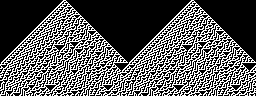

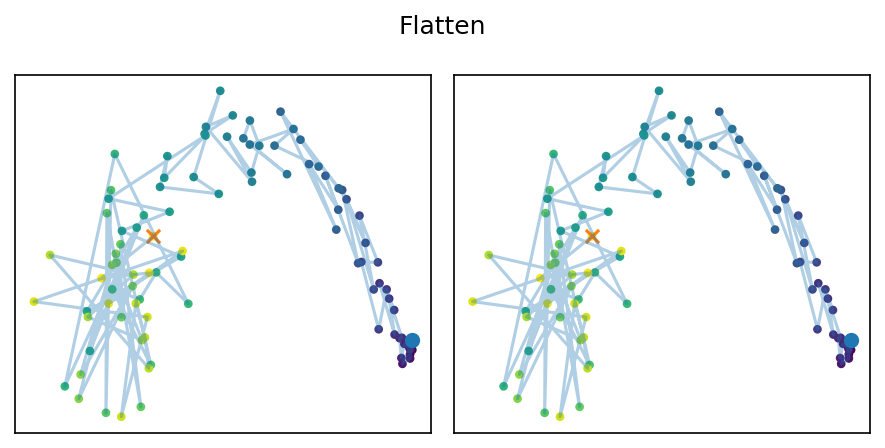

In [3]:
system = BinaryCA1D(kernel_size=3, device=device)
params = system.sample_params(B=2, device=device, kernel_size=3, rule_int=30)
x0 = system.seed(B=2, W=128, mode="single")
rollout = system.rollout(x0, params, steps=96)

z_flat = show(rollout, Flatten(spatial_dim=1, device=device))

## 1D coupled logistic lattice + RandomConvNet

rollout:   BinaryCA1D (2, 128, 1, 128)
extractor: RandomConvNet
embedding: (2, 128, 16)


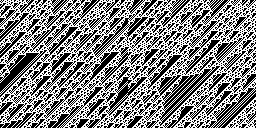

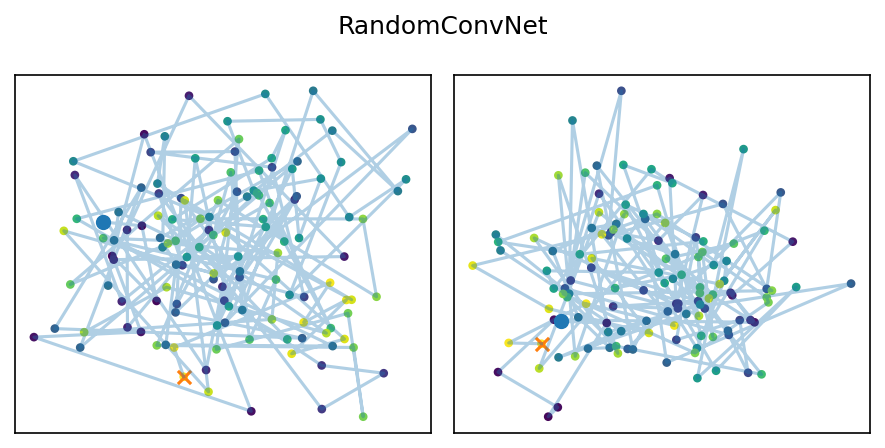

In [7]:
# system = CoupledLogistic1D(device=device)
system = BinaryCA1D(kernel_size=3)

# params = system.sample_params(B=2, device=device, r=(3.8, 3.95), eps=(0.15, 0.35))
params = system.sample_params(B=2, device=device, rule_int=106)
x0 = system.seed(B=2, W=128, mode="noise")
rollout = system.rollout(x0, params, steps=128)

z_cnn_1d = show(
    rollout,
    RandomConvNet(
        spatial_dim=1,
        embed_dim=16,
        base_channels=4,
        num_stages=3,
        layers_per_stage=2,
        reduction="gram",
        norm="instance",
        activation="tanh",
        use_pooling=False,
        kernel_size=5,
        kernel_growth=2,
        seed=1,
        device=device,
    ),
)

## 2D Conway life + RandomConvNet

In [28]:
rollout.to_continuous().shape

torch.Size([2, 128, 2, 64, 64])

rollout:   BinaryCA2D (2, 128, 1, 64, 64)
extractor: RandomVGG
embedding: (2, 128, 32)


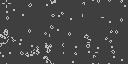

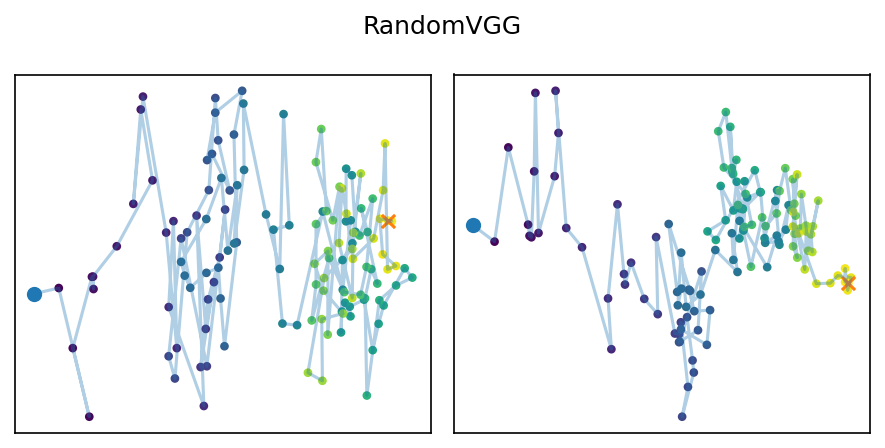

In [25]:
system = BinaryCA2D(device=device)
params = {"rule": system.bs_rule("B3/S23", device=device)}
x0 = system.seed(B=2, H=64, W=64, mode="noise", p=0.2)
rollout = system.rollout(x0, params, steps=256, every=2)

z_cnn_2d = show(
    rollout,
    RandomConvNet(
        spatial_dim=2,
        embed_dim=32,
        base_channels=16,
        num_stages=3,
        layers_per_stage=2,
        reduction="avg",
        norm="instance",
        activation="tanh",
        use_pooling=False,
        kernel_size=5,
        kernel_growth=2,
        seed=2,
        device=device,
    ),
)

## 2D Langton CA + RandomVGG

rollout:   LangtonCA2D (2, 40, 1, 48, 48)
extractor: RandomVGG
embedding: (2, 40, 32)


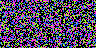

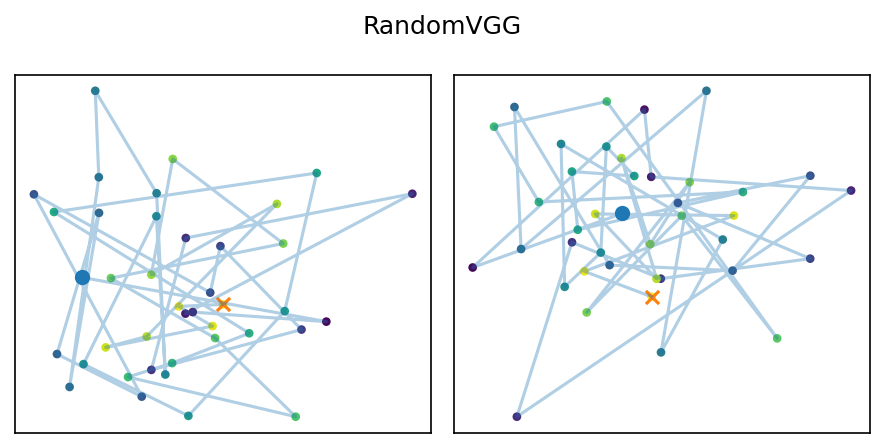

In [6]:
system = LangtonCA2D(num_states=4, kernel_size=3, device=device)
params = system.sample_params(B=2, device=device, lambda_=0.55, seed=(0, 10_000))
x0 = system.seed(B=2, H=48, W=48, mode="noise")
rollout = system.rollout(x0, params, steps=80, every=2)

z_vgg = show(
    rollout,
    RandomVGG(spatial_dim=2, embed_dim=32, channels=(16, 32), convs_per_block=2, seed=3, device=device),
)

## Optional: 2D rollout + CLIP

In [7]:
try:
    z_clip = show(rollout, CLIP(embed_dim=32, device=device), chunk=8)
except Exception as e:
    print(f"CLIP unavailable: {e}")

CLIP unavailable: No module named 'open_clip'
